In [19]:
# two sample t-test for PM2.5 and PM10
import pandas as pd
import numpy as np
from scipy import stats

dataset = pd.read_csv("Updated Leeds center air quality data 2020.csv", parse_dates=['End Date'])
dataset_PM25 = dataset[' PM25']
dataset_PM10 = dataset[' PM10']
#find variance for each group
var_PM25, var_PM10 = np.var(dataset_PM25), np.var(dataset_PM10)
ratio = max(var_PM25, var_PM10)/min(var_PM25, var_PM10)
print("The variance ratio is: ", ratio)

alpha = 0.05
#perform two sample t-test with equal variances
t2, p = stats.ttest_ind(a=dataset_PM25, b=dataset_PM10, equal_var=True)
print("p value = {:g}".format(p))
print("t value = {:g}". format(t2))

if p < alpha:  # null hypothesis: x comes from a normal distribution
    print("The null hypothesis can be rejected")
else:
    print("The null hypothesis is accepted")

The variance ratio is:  1.6487408377097543
p value = 1.29824e-281
t value = -36.5266
The null hypothesis can be rejected


In [80]:
#one way anova
import pandas as pd
import numpy as np
from scipy import stats

dataset = pd.read_csv("Updated Leeds center air quality data 2020.csv", parse_dates=['End Date'])
df = pd.DataFrame(dataset, columns = ['End Date', ' PM25'])

dg = df.groupby(pd.Grouper(key='End Date', freq='1M')).mean() # groupby each 1 month
dg.index = dg.index.strftime('%B')
#print(dg)
fvalue, pvalue = stats.f_oneway(df[' PM25'][df['End Date'].dt.month == 1],
                                df[' PM25'][df['End Date'].dt.month == 2],
                                df[' PM25'][df['End Date'].dt.month == 3],
                                df[' PM25'][df['End Date'].dt.month == 4],
                                df[' PM25'][df['End Date'].dt.month == 5],
                                df[' PM25'][df['End Date'].dt.month == 6],
                                df[' PM25'][df['End Date'].dt.month == 7],
                                df[' PM25'][df['End Date'].dt.month == 8],
                                df[' PM25'][df['End Date'].dt.month == 9],
                                df[' PM25'][df['End Date'].dt.month == 10],
                                df[' PM25'][df['End Date'].dt.month == 11],
                                df[' PM25'][df['End Date'].dt.month == 12])
print("F Value  = {:g} ".format(fvalue))
print("P Value  = {:g} ".format(pvalue))

alpha = 0.05 
if pvalue < alpha:  # null hypothesis: x comes from a normal distribution
    print("The null hypothesis can be rejected")
else:
    print("The null hypothesis is accepted")

F Value  = 19.6278 
P Value  = 1.22217e-39 
The null hypothesis can be rejected




Pearson Standard Correlation Coefficient Matrix
                 CO      PM10     M_DIR    M_SPED       M_T        NO  \
CO         1.000000  0.356804  0.090516 -0.181018 -0.246453  0.712042   
 PM10      0.356804  1.000000 -0.159539 -0.309350 -0.119635  0.384806   
 M_DIR     0.090516 -0.159539  1.000000  0.120025 -0.084677  0.000245   
 M_SPED   -0.181018 -0.309350  0.120025  1.000000  0.124413 -0.203648   
 M_T      -0.246453 -0.119635 -0.084677  0.124413  1.000000 -0.145681   
 NO        0.712042  0.384806  0.000245 -0.203648 -0.145681  1.000000   
 NO2       0.603549  0.428026  0.111880 -0.257025 -0.340547  0.611733   
 NOXasNO2  0.739440  0.448338  0.053679 -0.251864 -0.255130  0.925624   
 O3       -0.381001 -0.179857 -0.158017  0.284071  0.303272 -0.438919   
 PM25      0.365675  0.928344 -0.139760 -0.320240 -0.219859  0.348199   
 SO2       0.191274  0.260614 -0.054182 -0.072662 -0.012527  0.250226   

                NO2   NOXasNO2        O3      PM25       SO2  
CO        

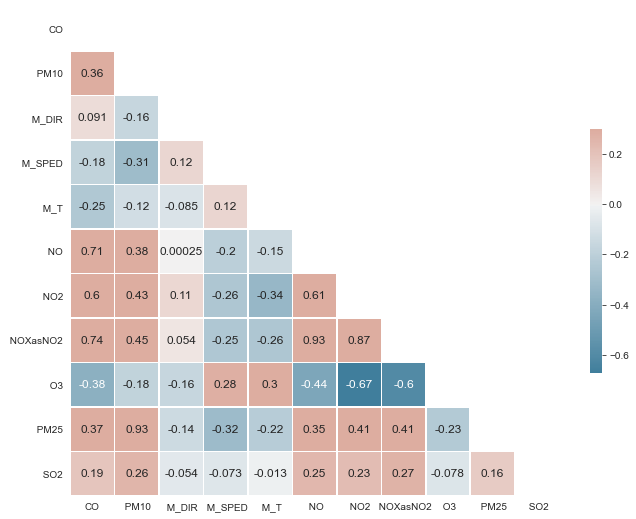

In [86]:
# pearson correlation
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

dataset = pd.read_csv("Updated Leeds center air quality data 2020.csv", parse_dates=['End Date'])

correlation = dataset.corr()
print("\n")
print("Pearson Standard Correlation Coefficient Matrix")
print(correlation)
print("\n")

 
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(correlation, dtype=bool))
 

#Set up matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))
 
#Set up a seaborn heatmap
#seaborne aesthetics https://seaborn.pydata.org/tutorial/aesthetics.html 
sns.set_style("white")
 
# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)
 
#Turn on annotations for correlation values
#annot = True
#annot_kws = {"size": 12}
 
# Draw the heatmap with the mask and correct aspect ratio
heatmap = sns.heatmap(correlation, mask = mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5},
            annot = True, annot_kws = {"size": 12})
 
#Add ticks for labels
sns.set_style({'xtick.bottom': True}, {'ytick.left': True})
 
#Export heatmap as an image
heatmap.get_figure().savefig('heatmap_diabetes.png', bbox_inches='tight')